In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("AI_Resume_Screening.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 11)


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [2]:
print(df.columns.tolist())

['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.isnull().sum()

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

In [5]:
df.describe(include='all')

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000,1000,1000.000000,1000,726,1000,1000,1000.000000,1000.00000,1000.000000
unique,NaN,989,238,NaN,5,3,4,2,NaN,NaN,NaN
top,NaN,Sarah Jones,"Ethical Hacking, Networking",NaN,B.Sc,Deep Learning Specialization,AI Researcher,Hire,NaN,NaN,NaN
freq,NaN,3,11,NaN,205,255,257,812,NaN,NaN,NaN
mean,500.500000,NaN,NaN,4.896000,NaN,NaN,NaN,NaN,79994.486000,5.13300,83.950000
std,288.819436,NaN,NaN,3.112695,NaN,NaN,NaN,NaN,23048.472549,3.23137,20.983036
min,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,40085.000000,0.00000,15.000000
25%,250.750000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,60415.750000,2.00000,70.000000
50%,500.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,79834.500000,5.00000,100.000000
75%,750.250000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,99583.250000,8.00000,100.000000


In [6]:
df = df.copy()

df['Certifications'] = df['Certifications'].fillna('No Certification')

df.drop_duplicates(inplace=True)

print(df.shape)

(1000, 11)


In [7]:
df.isnull().sum()

Resume_ID                 0
Name                      0
Skills                    0
Experience (Years)        0
Education                 0
Certifications            0
Job Role                  0
Recruiter Decision        0
Salary Expectation ($)    0
Projects Count            0
AI Score (0-100)          0
dtype: int64

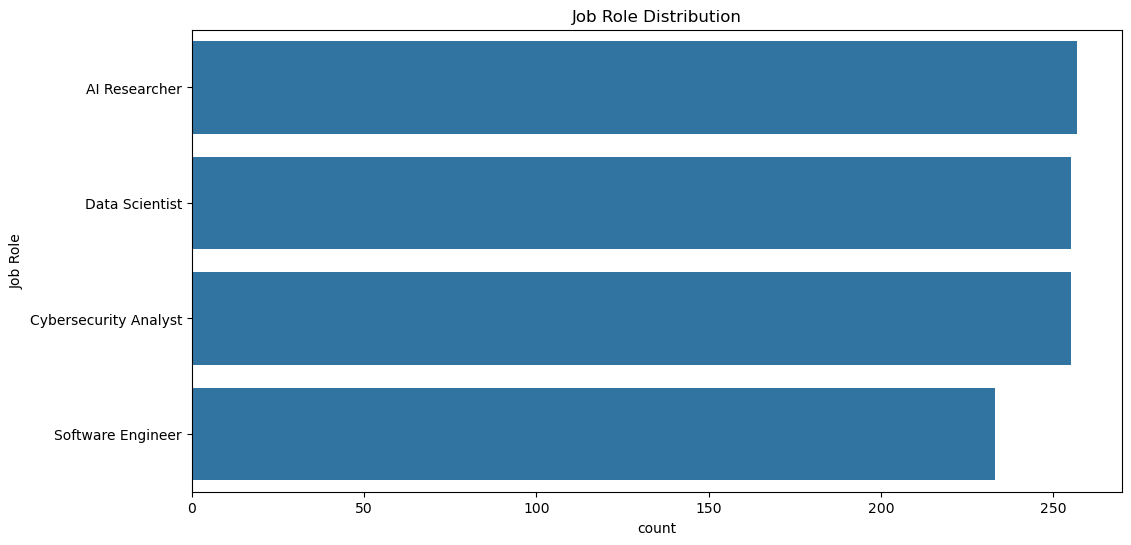

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(y=df['Job Role'],
              order=df['Job Role'].value_counts().index)

plt.title("Job Role Distribution")
plt.show()

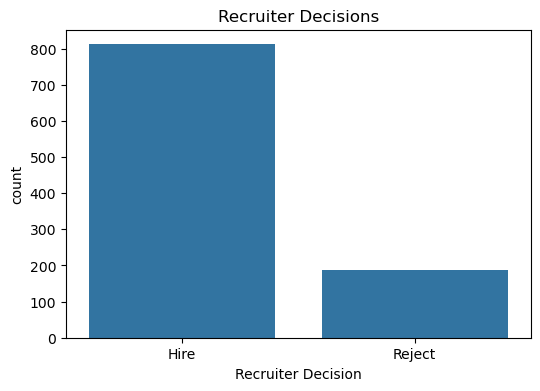

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Recruiter Decision'])

plt.title("Recruiter Decisions")
plt.show()

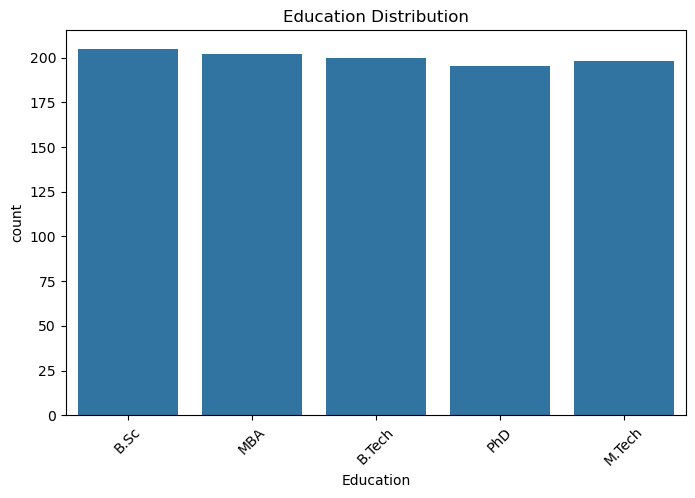

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Education'])

plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

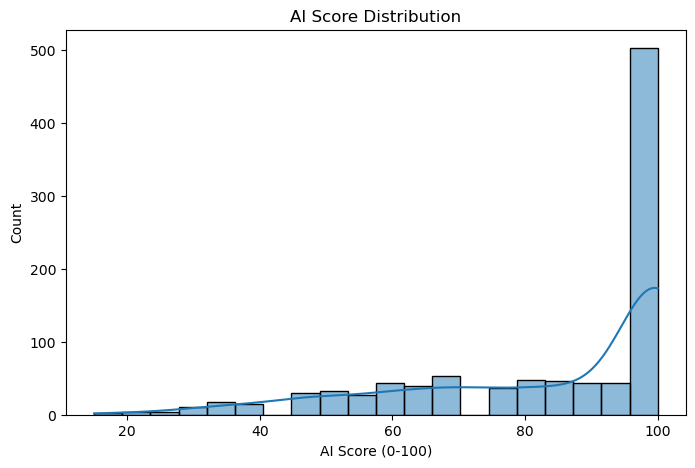

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['AI Score (0-100)'],
             bins=20,
             kde=True)

plt.title("AI Score Distribution")
plt.show()

In [12]:
df['combined_text'] = (
    df['Skills'].astype(str)
    + ' '
    + df['Education'].astype(str)
    + ' '
    + df['Certifications'].astype(str)
)

In [13]:
df[['combined_text']].head()

,combined_text
0,"TensorFlow, NLP, Pytorch B.Sc No Certification"
1,"Deep Learning, Machine Learning, Python, SQL M..."
2,"Ethical Hacking, Cybersecurity, Linux MBA Deep..."
3,"Python, Pytorch, TensorFlow B.Tech AWS Certified"
4,"SQL, React, Java PhD No Certification"


In [14]:
df['Job Role'].nunique()

4

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df['combined_text'])

print(X.shape)

(1000, 26)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['Job Role'])

print(le.classes_)

['AI Researcher' 'Cybersecurity Analyst' 'Data Scientist'
 'Software Engineer']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 26)
(200, 26)


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        51
           2       1.00      1.00      1.00        45
           3       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



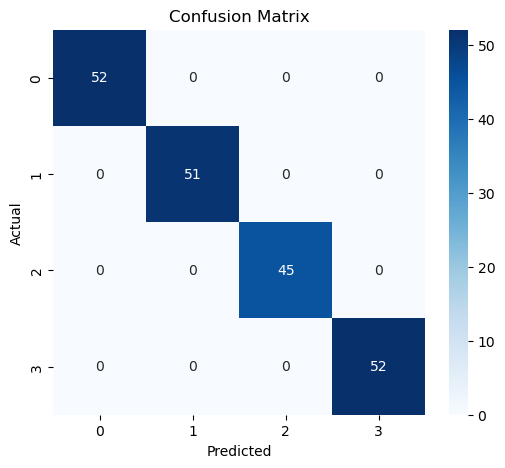

In [22]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

df[['Job Role','Cluster']].head()

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,Job Role,Cluster
0,AI Researcher,3
1,Data Scientist,1
2,Cybersecurity Analyst,0
3,AI Researcher,3
4,Software Engineer,2


In [24]:
print(df['Cluster'].value_counts())

Cluster
1    262
0    255
3    244
2    239
Name: count, dtype: int64


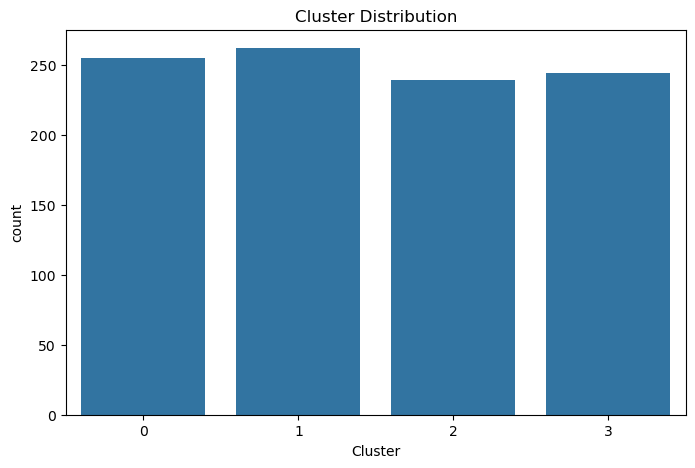

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['Cluster'])

plt.title("Cluster Distribution")
plt.show()

In [26]:
df['Candidate Score'] = (
    0.4 * df['AI Score (0-100)']
    + 2 * df['Experience (Years)']
    + 2 * df['Projects Count']
)

df['Candidate Score'] = df['Candidate Score'].round(2)

df[['Name','Job Role','Candidate Score']].head()

,Name,Job Role,Candidate Score
0,Ashley Ali,AI Researcher,76.0
1,Wesley Roman,Data Scientist,62.0
2,Corey Sanchez,Cybersecurity Analyst,44.0
3,Elizabeth Carney,AI Researcher,52.0
4,Julie Hill,Software Engineer,66.0


In [27]:
top_candidates = df.sort_values(
    by='Candidate Score',
    ascending=False
)

top_candidates[
    ['Name',
     'Job Role',
     'Candidate Score']
].head(10)

,Name,Job Role,Candidate Score
992,Michael Dodson,Software Engineer,80.0
823,Colleen Bates,Software Engineer,80.0
116,Mr. David Boyle,Cybersecurity Analyst,80.0
933,Kristina Evans,Data Scientist,80.0
402,Carlos Dawson,Cybersecurity Analyst,80.0
981,Dakota Clark,AI Researcher,80.0
828,Stephen Miller,AI Researcher,78.0
250,Timothy Smith,AI Researcher,78.0
591,Peter Thomas,Data Scientist,78.0
440,Zoe King,Data Scientist,78.0


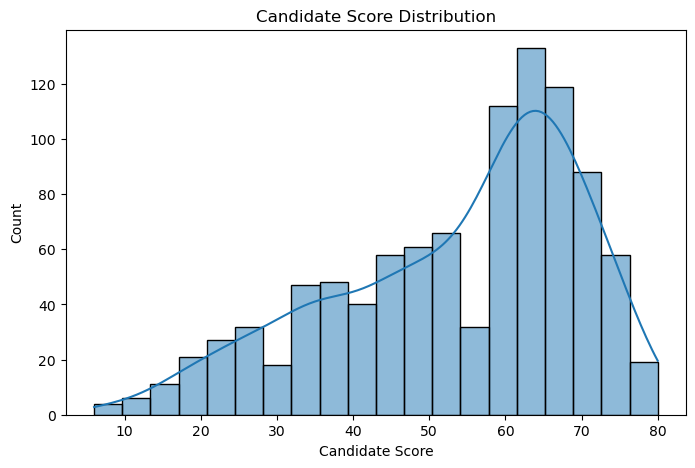

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Candidate Score'],
    bins=20,
    kde=True
)

plt.title("Candidate Score Distribution")
plt.show()

In [29]:
df.to_csv(
    "Final_Resume_Screening_Output.csv",
    index=False
)

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

cv_model = LogisticRegression(max_iter=3000)

scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [1.    0.995 1.    1.    0.995]
Average Accuracy: 0.998


In [31]:
feature_names = vectorizer.get_feature_names_out()

print("Total Features:", len(feature_names))
print(feature_names[:30])

Total Features: 26
['aws' 'certification' 'certified' 'cybersecurity' 'deep' 'ethical'
 'google' 'hacking' 'java' 'learning' 'linux' 'machine' 'mba' 'ml'
 'networking' 'nlp' 'no' 'phd' 'python' 'pytorch' 'react' 'sc'
 'specialization' 'sql' 'tech' 'tensorflow']


In [32]:
coef = model.coef_[0]

top_features = sorted(
    zip(coef, feature_names),
    reverse=True
)[:15]

for score, feature in top_features:
    print(feature, round(score,3))

pytorch 3.065
tensorflow 3.002
nlp 2.898
python 1.595
specialization 0.498
sc 0.213
tech -0.029
phd -0.052
mba -0.089
ml -0.112
google -0.112
certified -0.17
aws -0.17
no -0.186
certification -0.186


In [33]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 2.9 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


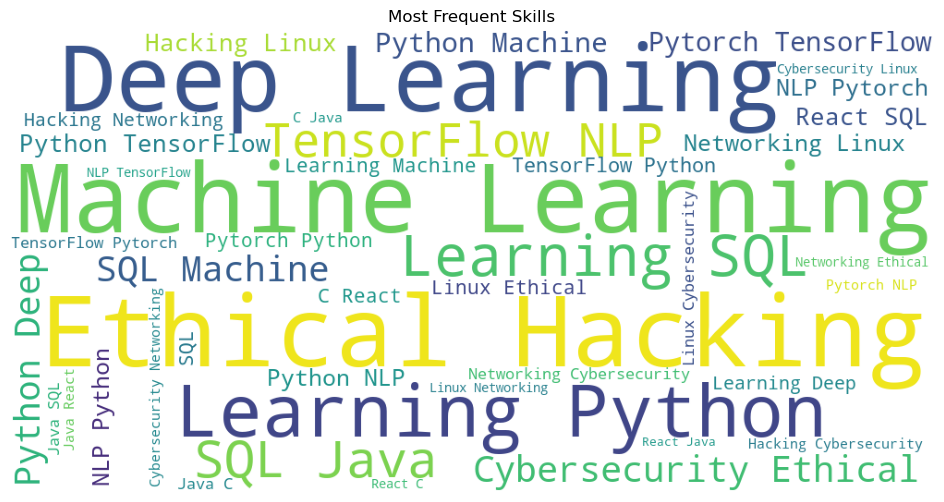

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Skills'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Skills")
plt.show()

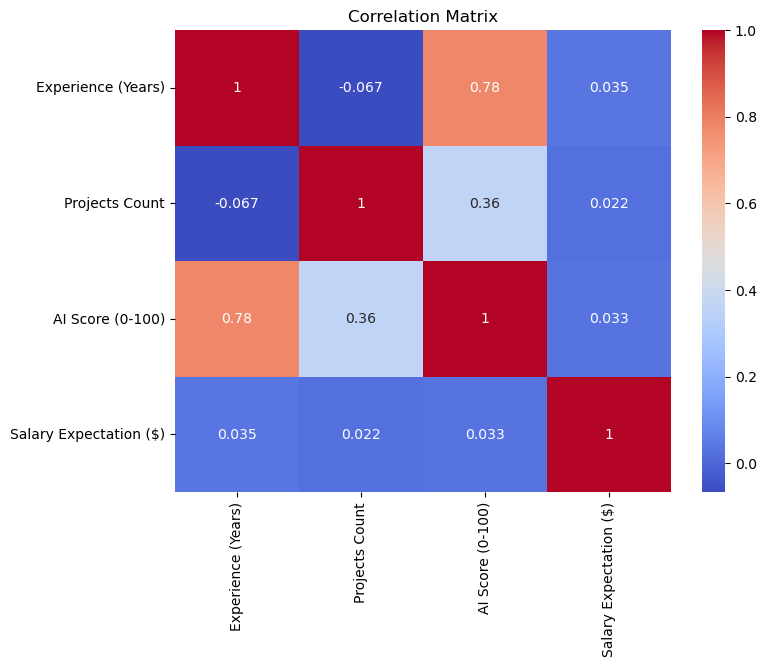

In [35]:
numeric_cols = [
    'Experience (Years)',
    'Projects Count',
    'AI Score (0-100)',
    'Salary Expectation ($)'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

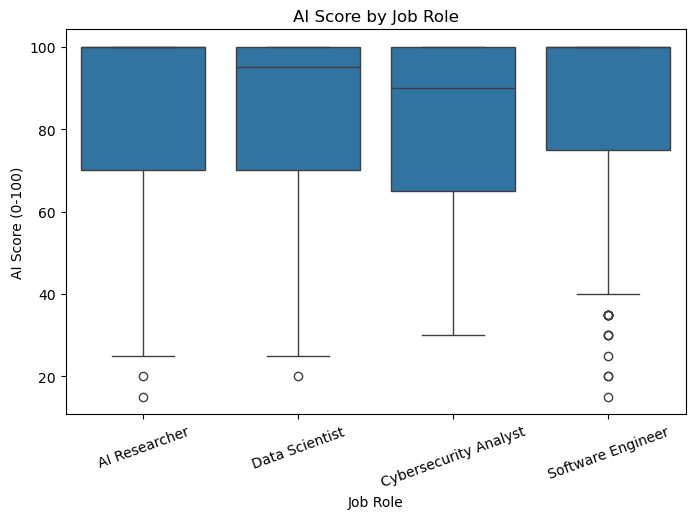

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Job Role',
    y='AI Score (0-100)',
    data=df
)

plt.xticks(rotation=20)
plt.title("AI Score by Job Role")
plt.show()

In [37]:
df.to_csv("Final_Resume_Screening_Output.csv", index=False)

print("File Saved Successfully")

File Saved Successfully


In [ ]:
# Conclusion

This project successfully developed an AI-Powered Resume Screening and Candidate Ranking System using Machine Learning and Natural Language Processing techniques.

TF-IDF vectorization was used to transform resume-related information into numerical features, and a Logistic Regression model was trained to predict job roles. The model achieved high accuracy in classifying candidate profiles.

K-Means clustering was applied to group similar candidates, while a candidate ranking system was developed using AI Score, Experience, and Project Count. The project demonstrates how AI can assist recruiters in automating resume screening and improving candidate selection efficiency.